# Tugas 09 Machine Learning

Muhammad Amir-0110222238-ML Senin Pagi

In [27]:
# Mengambil data pada google drive
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/MyDrive/NurulFikri/ML/Pertemuan09/data/data.csv')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [28]:
# Memanggil library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score  # Untuk memisahkan data menjadi set pelatihan dan pengujian
from sklearn.preprocessing import StandardScaler  # Dipakai untuk menormalkan fitur numerik sehingga rata-ratanya menjadi 0 dan standar deviasinya 1
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Alat ukur yang digunakan untuk mengevaluasi kinerja model
from sklearn.naive_bayes import GaussianNB  # Algoritma klasifikasi yang digunakan dalam proyek ini, yaitu Gaussian Naive Bayes

In [29]:
# Menampilkan baris data
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [30]:
# Menampilkan ringkasan dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [31]:
# Menghitung nilai yang hilang (Null)
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [32]:
# Menghapus kolom yang tidak relevan
df = df.drop(['id', 'Unnamed: 32'], axis=1)

In [33]:
# Encoding variabel
df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})

/tmp/ipython-input-292246813.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace({'M': 1, 'B': 0})


In [34]:
# Mengelompokkan data menjadi 2 komponen
X = df.drop('diagnosis', axis=1)
Y = df['diagnosis']

In [35]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
# membagi data yang ada menjadi empat set data yang terpisah.

print(X.shape,X_train.shape, X_test.shape)

(569, 30) (455, 30) (114, 30)


In [36]:
scaler = StandardScaler()  # Membuat objek dari kelas StandardScaler
X_train_scaled = scaler.fit_transform(X_train)  # Menghitung nilai standar dan sekaligus mengubah data pelatihan
X_test_scaled = scaler.transform(X_test)  # Mengonversi data pengujian menggunakan parameter yang diperoleh dari data pelatihan

In [37]:
nb_model = GaussianNB() # model yang akan digunakan untuk klasifikasi
nb_model.fit(X_train_scaled, Y_train) # melatih model menggunakan '(X_train_scaled, Y_train)'

GaussianNB()

In [38]:
train_pred_nb = nb_model.predict(X_train_scaled)  # Menghasilkan prediksi untuk data latih
test_pred_nb = nb_model.predict(X_test_scaled)  # Menghasilkan prediksi untuk data uji

print('Training Accuracy:', accuracy_score(Y_train, train_pred_nb))  # Menilai tingkat akurasi pada data pelatihan
print('Testing Accuracy:', accuracy_score(Y_test, test_pred_nb))  # Menilai tingkat akurasi pada data pengujian

Training Accuracy: 0.945054945054945
Testing Accuracy: 0.9210526315789473


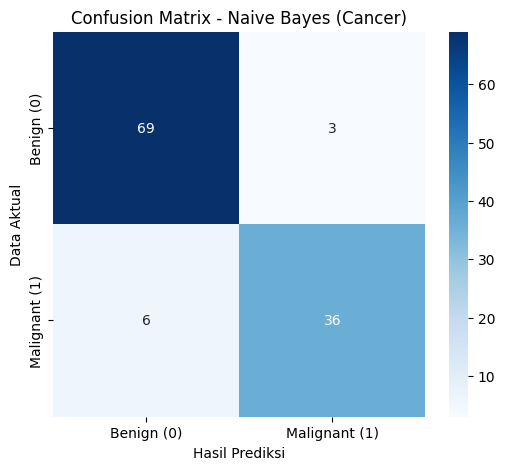

In [39]:
cm_nb = confusion_matrix(Y_test, test_pred_nb)  # Dipindahkan dari sel berikutnya untuk mendefinisikan cm_nb lebih awal
plt.figure(figsize=(6, 5))  # Membuat area gambar dengan ukuran tertentu
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])  # Menampilkan matriks kebingungan dalam bentuk heatmap

# Menambahkan keterangan pada grafik
plt.title('Confusion Matrix - Naive Bayes (Cancer)')
plt.ylabel('Data Aktual')
plt.xlabel('Hasil Prediksi')
plt.show()  # Memunculkan grafik

In [40]:
print("\nClassification Report (Testing Data):")  # Menampilkan ringkasan hasil evaluasi model
print(classification_report(Y_test, test_pred_nb, target_names=['Benign (0)', 'Malignant (1)']))
# ['Benign (0)', 'Malignant (1)'] = Menetapkan nama label yang lebih informatif untuk menggantikan label angka (0 dan 1)


Classification Report (Testing Data):
               precision    recall  f1-score   support

   Benign (0)       0.92      0.96      0.94        72
Malignant (1)       0.92      0.86      0.89        42

     accuracy                           0.92       114
    macro avg       0.92      0.91      0.91       114
 weighted avg       0.92      0.92      0.92       114



In [41]:
cm_nb = confusion_matrix(Y_test, test_pred_nb) # menghitung matriks
print("Confusion Matrix (Testing Data):\n", cm_nb) # menampilkan ringkasan testing data

Confusion Matrix (Testing Data):
 [[69  3]
 [ 6 36]]


In [42]:
cv_scores = cross_val_score(nb_model, X_train_scaled, Y_train, cv=5, scoring='accuracy')

print("\nNaive Bayes Cross Validation Accuracy (5-fold):")
print(f"CV Scores: {cv_scores}") # menampilkan 5 nilai akurasi individual
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}") # menhitung rata-rata
print(f"Std Deviation CV: {cv_scores.std():.4f}") # menghitung standar deviasi


Naive Bayes Cross Validation Accuracy (5-fold):
CV Scores: [0.92307692 0.98901099 0.92307692 0.92307692 0.93406593]
Mean CV Accuracy: 0.9385
Std Deviation CV: 0.0256
